<a href="https://colab.research.google.com/github/CoreLogicLabs/E-Commerce-Sales-Customer-Analytics/blob/main/E_Commerce_Sales_%26_Customer_Analytics_Business_Intelligence_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce Sales & Customer Analytics: Business Intelligence Case Study

# Business Objective

This project analyzes 30,000 e-commerce transactions to identify:

- Revenue drivers
- Customer behavior
- Product performance
- Marketing effectiveness
- Profitability opportunities

The goal is to uncover revenue opportunities, customer behavior patterns, and profitability drivers through data analysis and visualization techniques.


# Data Source

This project uses the **E-Commerce Orders Dataset 2026**, a publicly available dataset published on Kaggle.

Dataset License: MIT License

The dataset is publicly available on Kaggle and is used solely for educational and portfolio purposes.

Dataset:
E-Commerce Orders Dataset 2026 | SCRA

Source:
https://www.kaggle.com/datasets/mmumairkhattak/e-commerce-orders-dataset-2026-scra

The dataset contains 30,000 e-commerce transactions and includes customer demographics, product information, sales metrics, discounts, shipping details, profitability indicators, and customer behavior attributes.

This analysis was conducted independently for portfolio and educational purposes.


# Dataset Quality Assessment

Before conducting any analysis, the dataset was examined to ensure data quality, consistency, and reliability.

The following validation checks were performed:

- Dataset dimensions
- Data types and column structure
- Missing values
- Duplicate records
- Statistical summary of numerical variables
- Distribution of categorical variables

### Key Findings

- The dataset contains **30,000 e-commerce transactions** and **41 features**.
- No missing values were detected.
- No duplicate records were found.
- The dataset includes a balanced mix of numerical and categorical variables.
- Customer, product, sales, shipping, marketing, and profitability information are available for each transaction.

### Initial Observations

- The average customer age is approximately **36 years**.
- Returning customers represent the largest customer segment.
- Fashion is the most frequently purchased product category.
- Transactions span multiple countries, cities, and product categories.
- The dataset appears clean, structured, and suitable for exploratory data analysis (EDA), business intelligence reporting, and profitability analysis.

This validation step confirms that the dataset is reliable and ready for further business analysis.

### Dataset Validation Result

The dataset successfully passed all quality checks.

✓ No missing values

✓ No duplicate records

✓ Consistent data types

✓ Complete customer, product, sales, and profitability information

The dataset is suitable for business intelligence, exploratory data analysis (EDA), and profitability analysis.

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
# @title
from google.colab import files

uploaded = files.upload()

Saving ecommerce_orders_dataset.csv to ecommerce_orders_dataset.csv


In [ ]:
# @title
df = pd.read_csv("ecommerce_orders_dataset.csv")

In [ ]:
# @title
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 30,000
Columns: 41


In [ ]:
# @title
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,Germany,Dubai,Loyal,PROD02374,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,2.91,68.20,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.40,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,France,London,Returning,PROD01378,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,4.91,38.73,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.10,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,India,Berlin,Returning,PROD01850,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,16.50,153.66,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.00,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,United States,Riyadh,Returning,PROD00545,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,16.02,298.37,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.40,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,India,Mumbai,Premium,PROD01398,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,7.60,105.75,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.60,2133.77,24.64,26.06,Winter,No,No


In [ ]:
# @title
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 30000 non-null  int64  
 1   Customer_ID              30000 non-null  object 
 2   Order_Date               30000 non-null  object 
 3   Year                     30000 non-null  int64  
 4   Month                    30000 non-null  int64  
 5   Day                      30000 non-null  int64  
 6   Day_Of_Week              30000 non-null  object 
 7   Quarter                  30000 non-null  int64  
 8   Customer_Age             30000 non-null  int64  
 9   Customer_Gender          30000 non-null  object 
 10  Country                  30000 non-null  object 
 11  City                     30000 non-null  object 
 12  Customer_Segment         30000 non-null  object 
 13  Product_ID               30000 non-null  object 
 14  Product_Category      

In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [ ]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe(include="all")

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
count,30000.00,30000,30000,30000.00,30000.00,30000.00,30000,30000.00,30000.00,30000,30000,30000,30000,30000,30000,30000,30000,30000.00,30000.00,30000.00,30000.00,30000,30000.00,30000.00,30000.00,30000,30000,30000,30000,30000,30000,30000.00,30000,30000,30000.00,30000.00,30000.00,30000.00,30000,30000,30000
unique,NaN,8683,1461,NaN,NaN,NaN,7,NaN,NaN,3,10,10,4,2500,8,32,10,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,6,3,6,4,4,5,NaN,5,2,NaN,NaN,NaN,NaN,4,2,2
top,NaN,CUST000031,2024-03-09,NaN,NaN,NaN,Monday,NaN,NaN,Female,Canada,London,Returning,PROD02344,Fashion,Men Clothing,Zenith,NaN,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Credit Card,Mobile,Organic Search,Standard,Standard,West,NaN,Delivered,No,NaN,NaN,NaN,NaN,Summer,No,No
freq,NaN,14,39,NaN,NaN,NaN,4327,NaN,NaN,14863,3099,3089,11987,27,6092,1591,3099,NaN,NaN,NaN,NaN,20429,NaN,NaN,NaN,5080,18538,5098,16049,16420,6060,NaN,19497,26967,NaN,NaN,NaN,NaN,7575,25550,22499
mean,615000.50,NaN,NaN,2024.49,6.53,15.72,NaN,2.51,36.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.82,3.08,12.62,49.43,NaN,10.32,29.14,379.00,NaN,NaN,NaN,NaN,NaN,NaN,4.44,NaN,NaN,4.05,4372.34,21.97,73.86,NaN,NaN,NaN
std,8660.40,NaN,NaN,1.12,3.46,8.78,NaN,1.12,11.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172.68,1.45,11.09,114.40,NaN,5.89,49.56,585.41,NaN,NaN,NaN,NaN,NaN,NaN,2.35,NaN,NaN,0.69,6811.03,9.08,113.48,NaN,NaN,NaN
min,600001.00,NaN,NaN,2023.00,1.00,1.00,NaN,1.00,18.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.84,1.00,0.00,0.00,NaN,0.00,0.26,6.67,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,1.00,20.00,3.00,0.27,NaN,NaN,NaN
25%,607500.75,NaN,NaN,2023.00,4.00,8.00,NaN,2.00,28.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.88,2.00,0.00,0.00,NaN,6.02,5.27,82.95,NaN,NaN,NaN,NaN,NaN,NaN,3.00,NaN,NaN,3.60,1029.64,15.68,16.64,NaN,NaN,NaN
50%,615000.50,NaN,NaN,2024.00,7.00,16.00,NaN,3.00,36.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.67,3.00,10.00,13.47,NaN,9.00,12.07,171.03,NaN,NaN,NaN,NaN,NaN,NaN,4.00,NaN,NaN,4.10,2073.36,21.87,37.00,NaN,NaN,NaN
75%,622500.25,NaN,NaN,2025.00,10.00,23.00,NaN,4.00,44.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128.57,4.00,20.00,44.82,NaN,14.22,29.44,388.19,NaN,NaN,NaN,NaN,NaN,NaN,6.00,NaN,NaN,4.60,4482.10,28.18,82.12,NaN,NaN,NaN


# Executive KPI Dashboard

This section presents the key business metrics used to evaluate overall performance.

The KPIs below provide a quick overview of:

- Revenue generation
- Profitability
- Order volume
- Customer purchasing behavior
- Return performance

These metrics serve as the foundation for the deeper analyses that follow.

## KPI Overview

The metrics above provide a high-level summary of business performance.

Key questions that will be explored in the following sections include:

- Which products generate the highest revenue?
- Which customer segments are most profitable?
- How do discounts affect profitability?
- Which marketing channels drive the most valuable customers?
- What factors contribute to product returns?

The next sections will investigate these questions in greater detail.

In [ ]:
# @title
total_revenue = df["Order_Amount"].sum()
total_profit = df["Profit_Amount"].sum()
total_orders = len(df)
average_order_value = df["Order_Amount"].mean()
return_rate = (
    (df["Returned"] == "Yes").mean() * 100
)
average_profit_margin = df["Profit_Margin_Percent"].mean()

In [ ]:
# @title
kpi_df = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Average Order Value",
        "Return Rate",
        "Average Profit Margin"
    ],
    "Value": [
        f"${total_revenue:,.2f}",
        f"${total_profit:,.2f}",
        f"{total_orders:,}",
        f"${average_order_value:,.2f}",
        f"{return_rate:.2f}%",
        f"{average_profit_margin:.2f}%"
    ]
})

kpi_df

,Metric,Value
0,Total Revenue,"$11,370,043.99"
1,Total Profit,"$2,215,916.27"
2,Total Orders,"30,000"
3,Average Order Value,$379.00
4,Return Rate,10.11%
5,Average Profit Margin,21.97%


## KPI Insights

The business generated approximately **$11.37 million** in revenue from **30,000 transactions**, resulting in an average order value of **379.00**

A total profit of **$2.22 million** was achieved, with an average profit margin of **21.97%**, indicating healthy profitability across the business.

The return rate stands at **10.11%**, meaning roughly one out of every ten orders is returned. While this is not uncommon in e-commerce, return behavior should be examined further to identify categories, products, or customer segments contributing most to returns.

Overall, the business demonstrates strong revenue generation and profitability, providing a solid foundation for deeper analysis of sales performance, customer behavior, and operational efficiency.

# Revenue Analysis

Revenue is one of the most important indicators of business performance.

This section examines:

- Revenue trends over time
- Revenue contribution by product category
- Revenue distribution across countries
- Top-performing products

The objective is to identify the primary drivers of revenue growth and uncover opportunities for business expansion.

In [ ]:
# @title
revenue_by_category = (
    df.groupby("Product_Category")["Order_Amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

revenue_by_category

,Product_Category,Order_Amount
0,Electronics,6320059.31
1,Home & Kitchen,1768963.43
2,Fashion,1323929.17
3,Sports,661447.69
4,Beauty,460243.32
5,Groceries,360727.15
6,Toys,279307.23
7,Books,195366.69


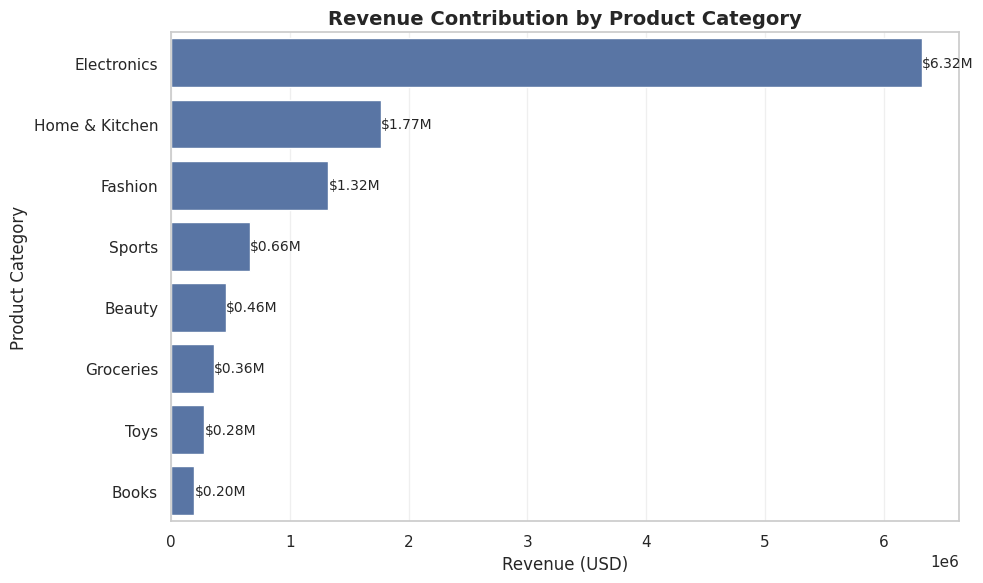

In [ ]:
# @title
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=revenue_by_category,
    x="Order_Amount",
    y="Product_Category"
)

plt.title(
    "Revenue Contribution by Product Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Revenue (USD)",
    fontsize=12
)

plt.ylabel(
    "Product Category",
    fontsize=12
)

# Revenue labels
for i, value in enumerate(revenue_by_category["Order_Amount"]):
    ax.text(
        value,
        i,
        f"${value/1_000_000:.2f}M",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

## Revenue Insights

Electronics is the dominant revenue-generating category, contributing approximately **55.6%** of total revenue.

Home & Kitchen and Fashion represent the second and third largest revenue streams, though their contribution remains significantly lower than Electronics.

The revenue distribution indicates a strong dependence on the Electronics category, suggesting that overall business performance is highly influenced by demand within this segment.

This concentration creates both opportunities and risks:

- Strong performance in Electronics can drive substantial revenue growth.
- Overreliance on a single category may increase business risk if market demand changes.
- Diversification opportunities may exist within Home & Kitchen and Fashion categories.

## Revenue by Country

Understanding geographic revenue distribution helps identify high-performing markets and potential expansion opportunities.

In [ ]:
# @title
revenue_by_country = (
    df.groupby("Country")["Order_Amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

revenue_by_country

,Country,Order_Amount
0,Saudi Arabia,1196810.50
1,United States,1188906.50
2,Canada,1182724.99
3,United Kingdom,1165387.89
4,Australia,1157750.50
5,India,1145311.33
6,France,1117231.28
7,UAE,1109749.70
8,Pakistan,1067444.22
9,Germany,1038727.08


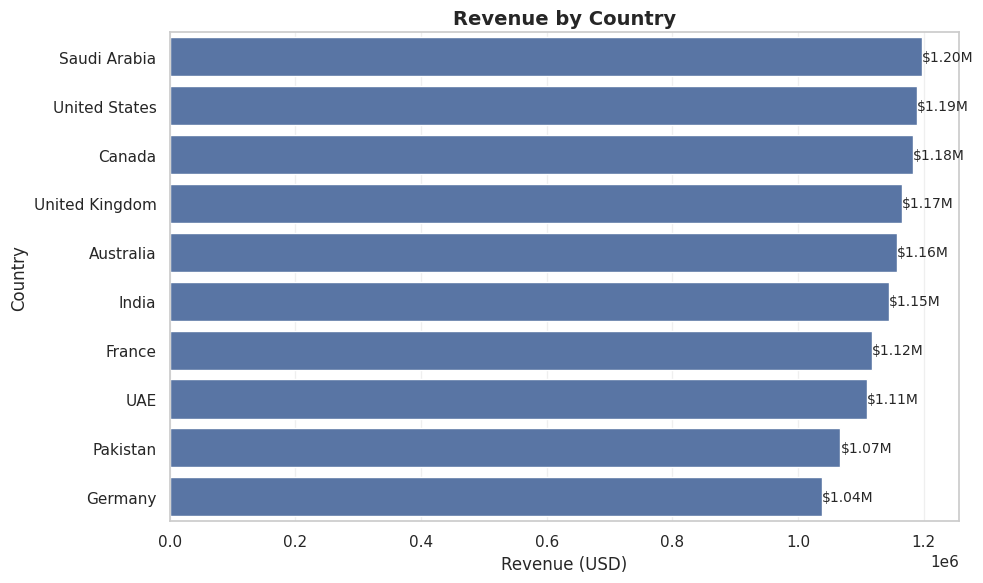

In [ ]:
# @title
revenue_by_country = (
    df.groupby("Country")["Order_Amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=revenue_by_country,
    x="Order_Amount",
    y="Country"
)

plt.title(
    "Revenue by Country",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Revenue (USD)",
    fontsize=12
)

plt.ylabel(
    "Country",
    fontsize=12
)

for i, value in enumerate(revenue_by_country["Order_Amount"]):
    ax.text(
        value,
        i,
        f"${value/1_000_000:.2f}M",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

## Geographic Revenue Insights

Revenue is relatively evenly distributed across all countries included in the dataset.

Saudi Arabia generated the highest revenue, followed closely by the United States and Canada. However, the difference between the top-performing and lowest-performing countries is relatively small.

This balanced distribution suggests that the business is not heavily dependent on a single geographic market.

Key observations:

- Revenue diversification is strong across regions.
- No single country dominates total revenue.
- Geographic risk exposure appears relatively low.
- Multiple international markets contribute significantly to overall business performance.

## Revenue Trend Over Time

Understanding revenue trends over time helps identify seasonality, growth patterns, and potential business opportunities.

This analysis examines how revenue changes throughout the year and highlights periods of strong and weak performance.

In [ ]:
# @title
monthly_revenue = (
    df.groupby("Month")["Order_Amount"]
      .sum()
      .reset_index()
)

monthly_revenue = monthly_revenue.sort_values("Month")

monthly_revenue

,Month,Order_Amount
0,1,936076.62
1,2,921195.64
2,3,1010299.50
3,4,924831.93
4,5,913148.58
5,6,918539.05
6,7,930656.68
7,8,1071268.49
8,9,919010.17
9,10,900354.21


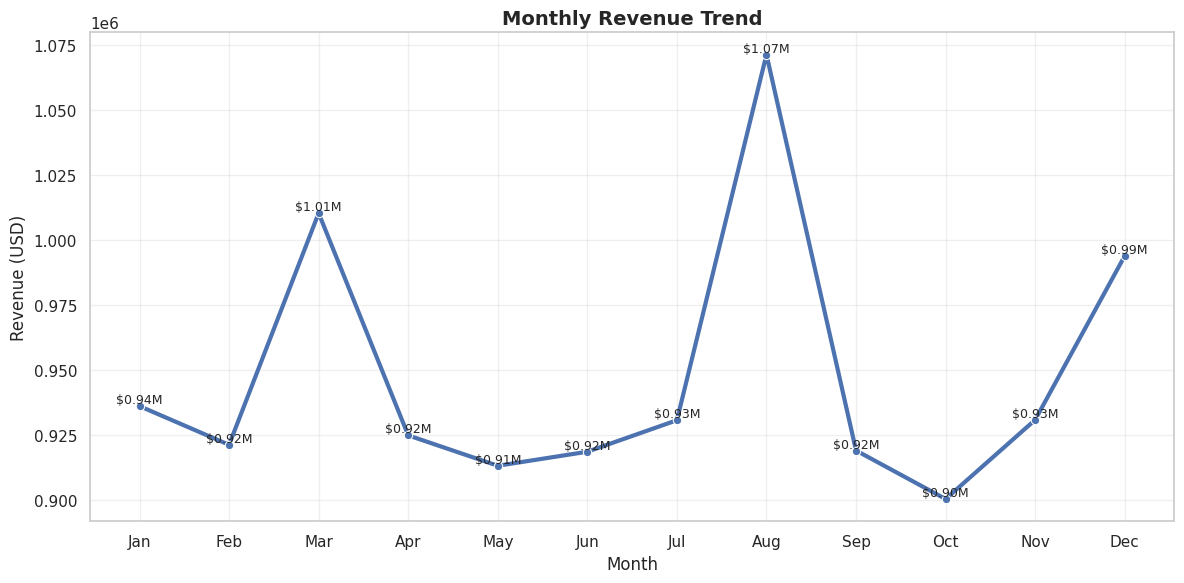

In [ ]:
# @title
# Revenue Trend Over Time

month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

monthly_revenue["Month_Name"] = (
    monthly_revenue["Month"]
    .map(month_names)
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x="Month_Name",
    y="Order_Amount",
    marker="o",
    linewidth=3
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Revenue (USD)",
    fontsize=12
)

# Revenue labels
for i, value in enumerate(monthly_revenue["Order_Amount"]):
    plt.text(
        i,
        value,
        f"${value/1_000_000:.2f}M",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Revenue Trend Insights

Revenue remained relatively stable throughout the year, with moderate fluctuations between months.

August generated the highest revenue, reaching approximately **USD 1.07 million**, while October recorded the lowest revenue at approximately **USD 0.90 million**.

A noticeable revenue increase is observed during March and August, suggesting potential seasonal demand patterns or successful promotional activities during these periods.

Key observations:

- Revenue performance remains relatively consistent throughout the year.
- August represents the strongest sales period.
- October shows the weakest revenue performance.
- Revenue recovers during the final months of the year.
- Seasonal effects appear moderate rather than extreme.

Overall, the business demonstrates stable revenue generation with limited seasonal dependency.

# Customer Analytics

Understanding customer demographics and behavior is essential for identifying high-value customer groups and improving business performance.

This section examines customer segments, demographics, and customer lifetime value to better understand the customer base.

In [ ]:
# @title
customer_segments = (
    df["Customer_Segment"]
      .value_counts()
      .reset_index()
)

customer_segments.columns = [
    "Customer_Segment",
    "Customer_Count"
]

customer_segments

,Customer_Segment,Customer_Count
0,Returning,11987
1,New,7794
2,Loyal,7214
3,Premium,3005


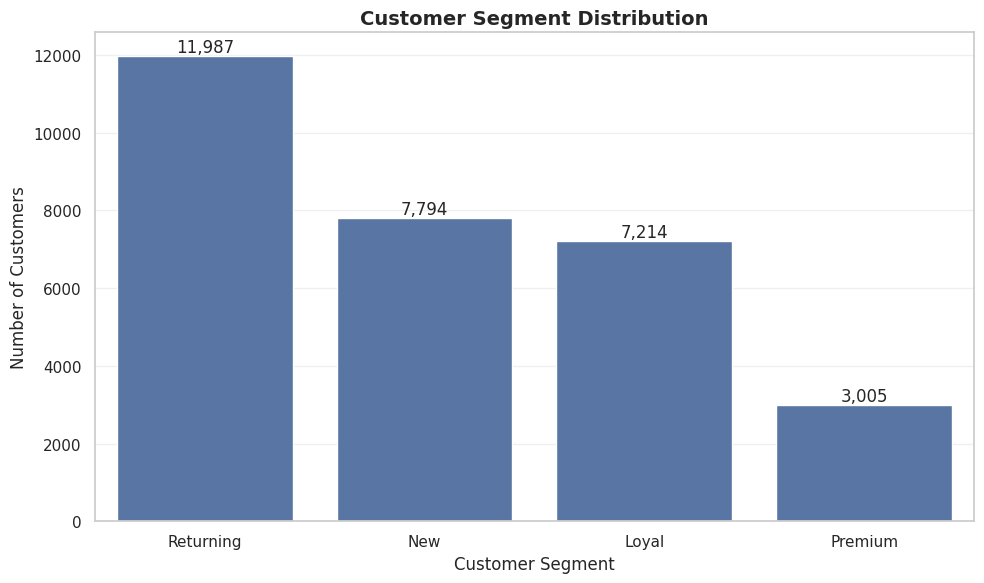

In [ ]:
# @title
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=customer_segments,
    x="Customer_Segment",
    y="Customer_Count"
)

plt.title(
    "Customer Segment Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Customer Segment",
    fontsize=12
)

plt.ylabel(
    "Number of Customers",
    fontsize=12
)

for i, value in enumerate(customer_segments["Customer_Count"]):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## Customer Segment Insights

Returning customers represent the largest customer segment, accounting for approximately **40%** of all customers.

This indicates that the business has established a strong base of repeat customers, which is generally associated with higher retention rates and lower customer acquisition costs.

New customers represent approximately **26%** of the customer base, while Loyal customers account for approximately **24%**. Premium customers form the smallest segment at approximately **10%**.

Key observations:

- Returning customers are the primary customer group.
- Customer retention appears to be a significant strength.
- Loyal customers represent a substantial share of the customer base.
- Premium customers offer potential opportunities for targeted marketing and upselling strategies.

Overall, the customer distribution suggests a healthy balance between customer acquisition and retention.

## Customer Age Distribution

Understanding the age profile of customers helps identify target demographics and support marketing strategy decisions.

This analysis examines the distribution of customer ages across the customer base.

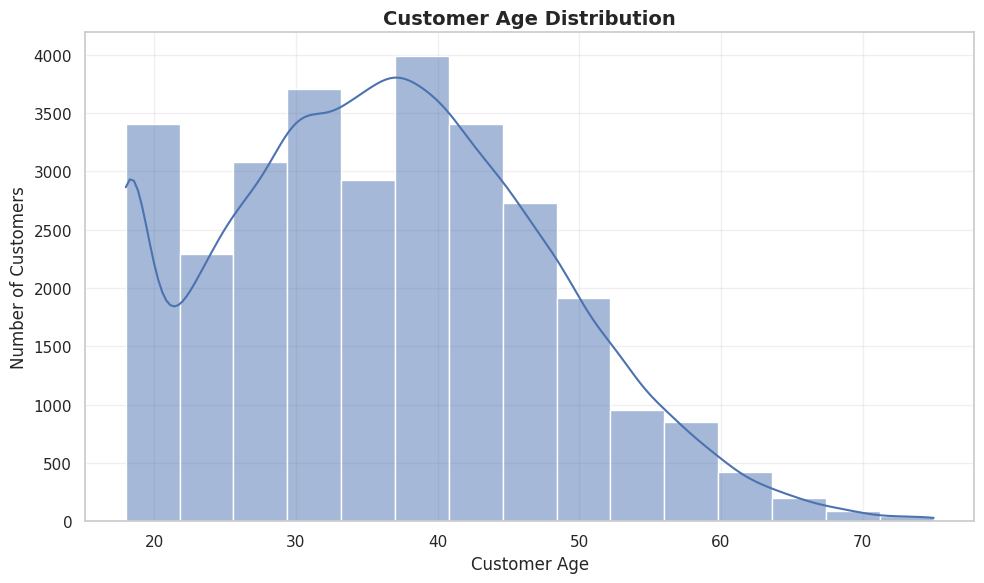

In [ ]:
# @title
plt.figure(figsize=(10,6))

sns.histplot(
    df["Customer_Age"],
    bins=15,
    kde=True
)

plt.title(
    "Customer Age Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Customer Age",
    fontsize=12
)

plt.ylabel(
    "Number of Customers",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Customer Age Insights

The customer base is primarily concentrated between the ages of **30 and 45**, indicating that middle-aged consumers represent the core target demographic.

Customer activity peaks around the late 30s, suggesting that individuals in this age group contribute significantly to overall business activity.

The number of customers gradually declines after age 50, while customers above 60 represent a relatively small portion of the customer base.

Key observations:

- Customers aged 30–45 form the largest demographic group.
- The highest concentration of customers is observed around age 38.
- Customer participation decreases steadily after age 50.
- The business appears to be particularly attractive to working-age consumers.

Overall, the age distribution suggests a strong focus on mature consumers with established purchasing power.

## Customer Gender Distribution

Understanding gender distribution helps identify key customer demographics and supports targeted marketing strategies.

In [ ]:
# @title
gender_distribution = (
    df["Customer_Gender"]
      .value_counts()
      .reset_index()
)

gender_distribution.columns = [
    "Gender",
    "Customer_Count"
]

gender_distribution

,Gender,Customer_Count
0,Female,14863
1,Male,14552
2,Other,585


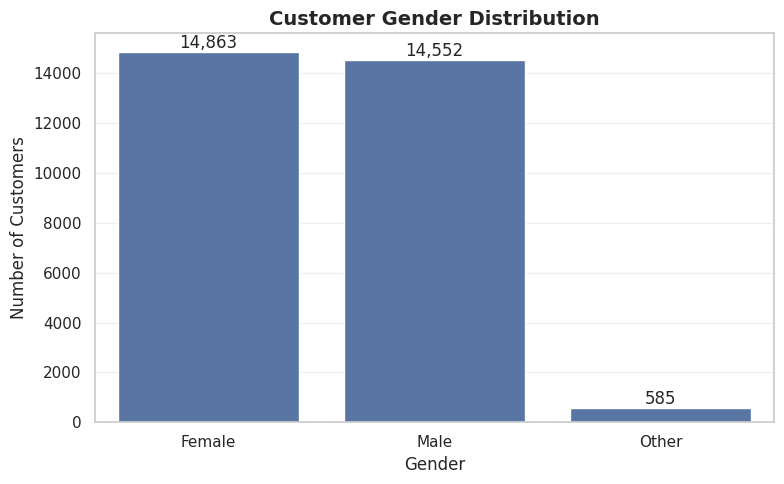

In [ ]:
# @title
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=gender_distribution,
    x="Gender",
    y="Customer_Count"
)

plt.title(
    "Customer Gender Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Number of Customers")

for i, value in enumerate(gender_distribution["Customer_Count"]):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Customer Gender Insights

The customer base is almost evenly distributed between male and female customers.

Female customers account for approximately **49.5%** of the customer base, while male customers represent approximately **48.5%**. Customers categorized as "Other" account for approximately **2%** of total customers.

This balanced distribution suggests that the business appeals to a broad audience and is not heavily dependent on a single gender demographic.

Key observations:

- Customer gender distribution is highly balanced.
- Female and male customer participation is nearly equal.
- The business demonstrates broad market appeal.
- Marketing campaigns can be designed for a diverse customer audience rather than focusing on a single demographic group.

Overall, the gender distribution indicates a well-diversified customer base with balanced engagement across demographic groups.

## Customer Lifetime Value Analysis

Customer Lifetime Value (CLV) measures the total value a customer contributes to the business over time.

Understanding CLV helps identify high-value customer groups and supports customer retention strategies.

In [ ]:
# @title
df["Customer_Lifetime_Value"].describe()

,Customer_Lifetime_Value
count,30000.00
mean,4372.34
std,6811.03
min,20.00
25%,1029.64
50%,2073.36
75%,4482.10
max,50000.00


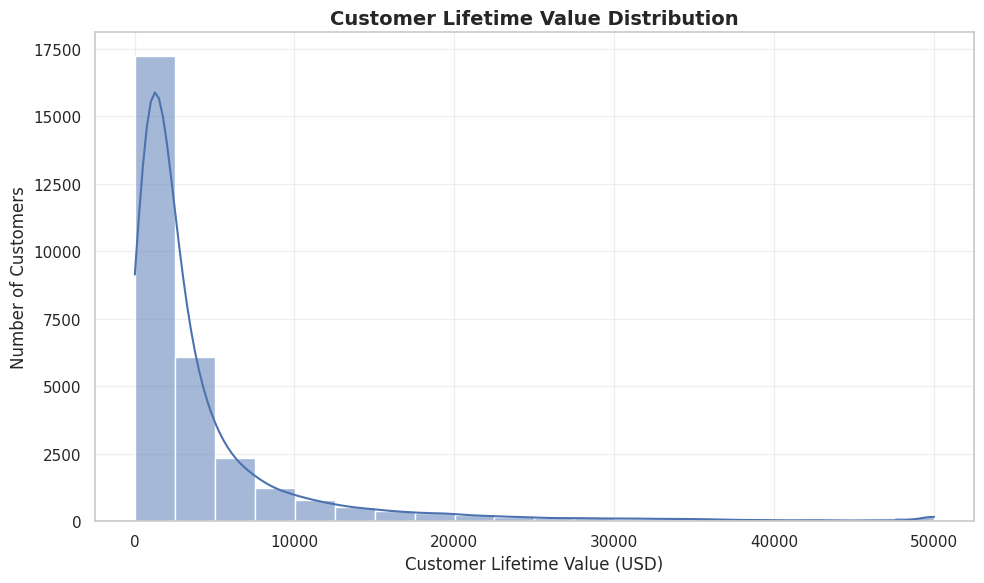

In [ ]:
# @title
plt.figure(figsize=(10,6))

sns.histplot(
    df["Customer_Lifetime_Value"],
    bins=20,
    kde=True
)

plt.title(
    "Customer Lifetime Value Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Customer Lifetime Value (USD)",
    fontsize=12
)

plt.ylabel(
    "Number of Customers",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Customer Lifetime Value Insights

The average Customer Lifetime Value (CLV) is approximately **USD 4,372**, while the median CLV is approximately **USD 2,073**.

The large difference between the mean and median indicates a highly right-skewed distribution, suggesting that a relatively small group of customers contributes disproportionately high lifetime value.

Most customers generate modest lifetime value, while a limited number of high-value customers significantly impact overall business performance.

Key observations:

- Average CLV exceeds median CLV by a substantial margin.
- High-value customers play a critical role in revenue generation.
- Customer value is unevenly distributed across the customer base.
- Retaining high-value customers should be a strategic priority.

Overall, the analysis highlights the importance of customer retention and personalized engagement strategies for high-value customer segments.

# Profitability Analysis

Revenue alone does not determine business success. Understanding profitability helps identify the products, categories, and business activities that generate the greatest financial value.

This section examines profit generation, profit margins, and factors affecting profitability.

In [ ]:
# @title
profit_by_category = (
    df.groupby("Product_Category")["Profit_Amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

profit_by_category

,Product_Category,Profit_Amount
0,Electronics,1040688.00
1,Home & Kitchen,379418.20
2,Fashion,344642.74
3,Sports,139758.27
4,Beauty,134401.18
5,Groceries,76057.26
6,Toys,60150.95
7,Books,40799.67


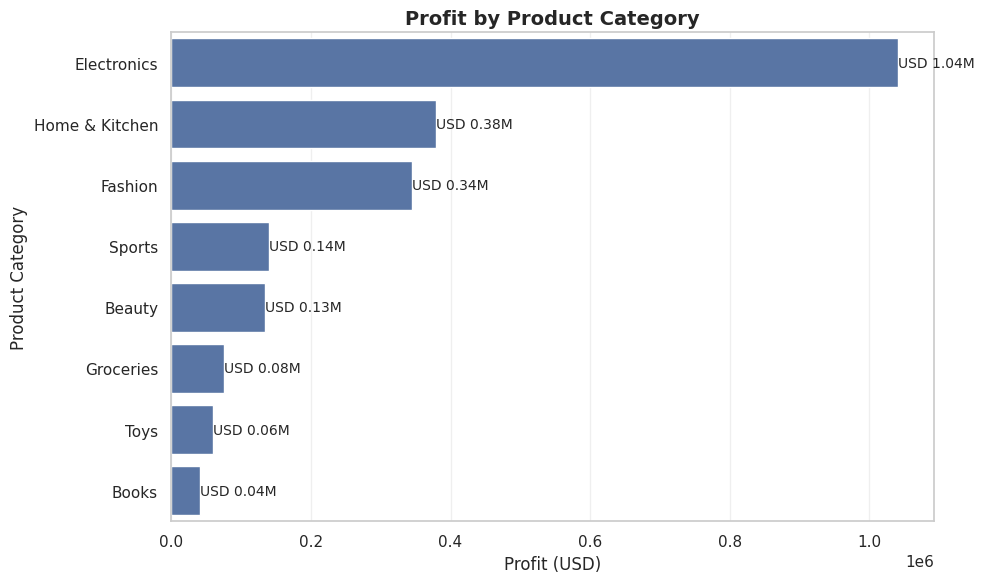

In [ ]:
# @title
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=profit_by_category,
    x="Profit_Amount",
    y="Product_Category"
)

plt.title(
    "Profit by Product Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Profit (USD)",
    fontsize=12
)

plt.ylabel(
    "Product Category",
    fontsize=12
)

for i, value in enumerate(profit_by_category["Profit_Amount"]):
    ax.text(
        value,
        i,
        f"USD {value/1_000_000:.2f}M",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Profitability Insights

Electronics is the most profitable product category, generating approximately **USD 1.04 million** in total profit.

Home & Kitchen and Fashion represent the second and third most profitable categories, contributing approximately **USD 0.38 million** and **USD 0.34 million**, respectively.

The profitability ranking closely mirrors the revenue ranking, indicating that the categories generating the highest sales also contribute the most profit.

Key observations:

- Electronics is the dominant profit driver.
- Home & Kitchen and Fashion provide meaningful secondary profit streams.
- Profit generation is concentrated within a small number of categories.
- Lower-performing categories contribute relatively little to overall profitability.

Overall, profitability is strongly influenced by Electronics sales, highlighting the strategic importance of this category.

## Profit Margin by Product Category

Profit margin provides a clearer view of profitability by showing how efficiently revenue is converted into profit.

This analysis compares average profit margins across product categories.

In [ ]:
# @title
margin_by_category = (
    df.groupby("Product_Category")["Profit_Margin_Percent"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

margin_by_category

,Product_Category,Profit_Margin_Percent
0,Beauty,28.89
1,Fashion,25.79
2,Toys,21.19
3,Home & Kitchen,21.19
4,Sports,20.88
5,Books,20.78
6,Groceries,20.75
7,Electronics,16.20


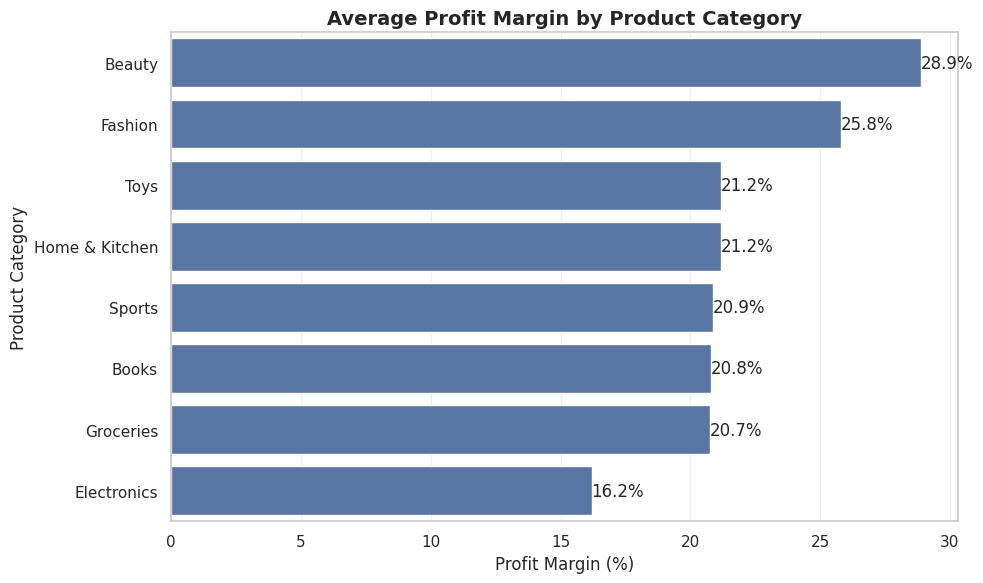

In [ ]:
# @title
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=margin_by_category,
    x="Profit_Margin_Percent",
    y="Product_Category"
)

plt.title(
    "Average Profit Margin by Product Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Profit Margin (%)",
    fontsize=12
)

plt.ylabel(
    "Product Category",
    fontsize=12
)

for i, value in enumerate(margin_by_category["Profit_Margin_Percent"]):
    ax.text(
        value,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Profit Margin Insights

While Electronics generates the highest total profit, it records the lowest average profit margin among all product categories at approximately **16.2%**.

In contrast, Beauty achieves the highest average profit margin at approximately **28.9%**, followed by Fashion at approximately **25.8%**.

This indicates that high revenue does not necessarily translate into high profitability efficiency.

Key observations:

- Beauty is the most efficient category in terms of profit generation.
- Fashion also delivers strong profitability relative to revenue.
- Electronics relies heavily on sales volume rather than high margins.
- Lower-revenue categories can still contribute meaningful profitability through stronger margins.

Overall, the analysis suggests that margin-focused growth opportunities may exist within Beauty and Fashion, while Electronics remains the primary volume-driven category.

## Impact of Discounts on Profitability

Discounts can increase sales volume, but excessive discounting may reduce profitability.

This analysis examines the relationship between discount percentages and profit margins.

In [ ]:
# @title
discount_profit = (
    df.groupby("Discount_Percent")["Profit_Margin_Percent"]
      .mean()
      .reset_index()
)

discount_profit

,Discount_Percent,Profit_Margin_Percent
0,0,24.99
1,5,23.89
2,10,22.54
3,15,21.43
4,20,19.89
5,25,19.18
6,30,18.02
7,35,16.68
8,40,15.36


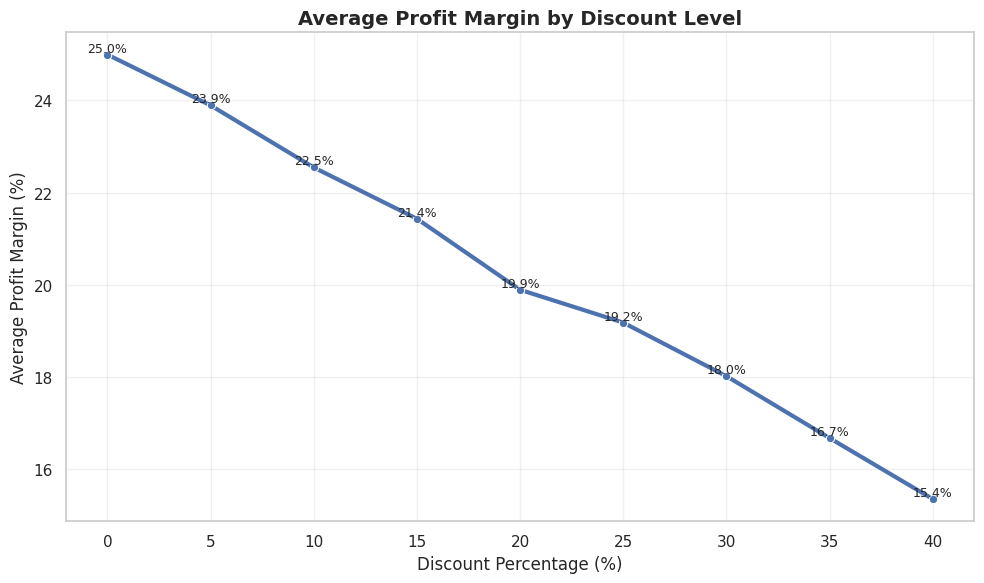

In [ ]:
# @title
plt.figure(figsize=(10,6))

ax = sns.lineplot(
    data=discount_profit,
    x="Discount_Percent",
    y="Profit_Margin_Percent",
    marker="o",
    linewidth=3
)

plt.title(
    "Average Profit Margin by Discount Level",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Discount Percentage (%)",
    fontsize=12
)

plt.ylabel(
    "Average Profit Margin (%)",
    fontsize=12
)

for x, y in zip(
    discount_profit["Discount_Percent"],
    discount_profit["Profit_Margin_Percent"]
):
    plt.text(
        x,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Discount Impact Insights

A clear negative relationship exists between discount levels and profit margins.

As discount percentages increase, average profit margins decline consistently. Products sold without discounts achieve an average profit margin of approximately **25.0%**, while products sold with a **40% discount** achieve an average margin of only **15.4%**.

The analysis suggests that aggressive discounting significantly reduces profitability.

Key observations:

- Profit margins decrease steadily as discount levels increase.
- Higher discounts are associated with lower profitability.
- Products with no discounts generate the strongest margins.
- Discounts should be used strategically rather than applied broadly.

Overall, the findings highlight the importance of balancing sales growth objectives with profitability considerations when designing discount strategies.

# Return Analysis

Product returns can have a significant impact on revenue, profitability, and customer satisfaction.

This section examines return patterns across product categories and customer groups.

In [ ]:
# @title
returns_by_category = (
    df.groupby("Product_Category")["Returned"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
      .reset_index()
)

returns_by_category.columns = [
    "Product_Category",
    "Return_Rate"
]

returns_by_category

,Product_Category,Return_Rate
0,Fashion,13.87
1,Books,10.91
2,Sports,9.80
3,Electronics,9.19
4,Groceries,8.83
5,Toys,8.83
6,Beauty,8.78
7,Home & Kitchen,8.66


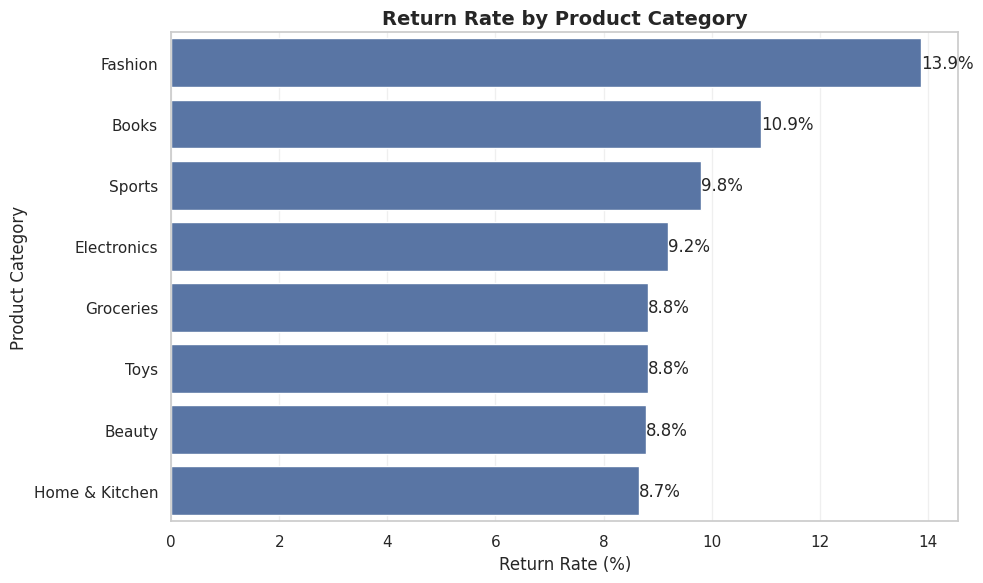

In [ ]:
# @title
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=returns_by_category,
    x="Return_Rate",
    y="Product_Category"
)

plt.title(
    "Return Rate by Product Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Return Rate (%)",
    fontsize=12
)

plt.ylabel(
    "Product Category",
    fontsize=12
)

for i, value in enumerate(returns_by_category["Return_Rate"]):
    ax.text(
        value,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Return Analysis Insights

Fashion records the highest return rate at approximately **13.9%**, making it the category most affected by product returns.

Books and Sports also exhibit relatively elevated return rates compared to other categories.

Interestingly, Electronics — despite being the largest revenue and profit contributor — maintains a return rate of approximately **9.2%**, which is below the overall return leader.

Key observations:

- Fashion represents the highest return-risk category.
- Electronics generates strong revenue without excessive return activity.
- Return rates vary across product categories, suggesting category-specific customer expectations and purchasing behavior.
- Lower return rates in high-revenue categories contribute positively to overall profitability.

Overall, return management efforts should primarily focus on Fashion products, where improvements in product descriptions, sizing accuracy, and customer expectations may reduce return volumes.

# Executive Summary & Business Recommendations

This section summarizes the key findings of the analysis and provides strategic recommendations based on the observed patterns in sales, customer behavior, profitability, and returns.

## Key Findings

### Revenue Performance
- Total revenue reached approximately **USD 11.37 million**.
- Electronics was the largest revenue-generating category.
- Revenue remained relatively stable throughout the year, with August representing the strongest sales period.

### Customer Analytics
- Returning customers represented approximately **40%** of the customer base.
- The average customer age was approximately **36 years**.
- Gender distribution was nearly balanced between male and female customers.
- Customer Lifetime Value distribution was highly skewed, indicating the presence of valuable high-spending customer segments.

### Profitability
- Total profit exceeded **USD 2.21 million**.
- Electronics generated the highest absolute profit.
- Beauty and Fashion achieved the highest profit margins.
- Higher discount levels were consistently associated with lower profit margins.

### Returns
- The overall return rate was approximately **10.1%**.
- Fashion products experienced the highest return rates.
- Electronics maintained relatively moderate return rates despite strong sales volume.

## Business Recommendations

Based on the analysis, the following strategic recommendations are proposed:

1. Expand and promote high-margin categories such as Beauty and Fashion.

2. Continue investing in Electronics due to its strong contribution to revenue and profit.

3. Reduce excessive discounting and prioritize targeted promotional campaigns.

4. Develop retention programs focused on high-value customers with elevated Customer Lifetime Value.

5. Investigate return drivers within the Fashion category to reduce return-related costs.

6. Utilize customer segmentation insights to personalize marketing campaigns and improve customer engagement.

By implementing these strategies, the business may improve profitability, strengthen customer retention, and support sustainable long-term growth.